In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_ta as ta
import optuna
import math

In [2]:
def load_candles(base,quote,timeframe):
    data = pd.read_json(f'/media/mu6mula/Data/Crypto-Data-Feed/freq-user-data/data/binance/{base}_{quote}-{timeframe}.json')
    data.columns = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
    data['timestamp'] = pd.to_datetime(data['timestamp'], unit='ms')
    data.set_index('timestamp', inplace=True)
    return data

In [7]:

# Load the data
data = load_candles('ETH','USDT','8h')
data = data['2021-11-01':].copy()


[I 2024-08-03 22:41:24,135] A new study created in memory with name: no-name-bed042f6-e8dd-4869-902b-18fdf9a954dc
[I 2024-08-03 22:41:24,144] Trial 0 finished with value: 1.0774768433649453 and parameters: {'tenkan_period': 23, 'kijun_period': 83, 'senkou_span_b_period': 13}. Best is trial 0 with value: 1.0774768433649453.
[I 2024-08-03 22:41:24,152] Trial 1 finished with value: 1.0540771143394043 and parameters: {'tenkan_period': 45, 'kijun_period': 60, 'senkou_span_b_period': 9}. Best is trial 0 with value: 1.0774768433649453.
[I 2024-08-03 22:41:24,158] Trial 2 finished with value: 1.0621951288812141 and parameters: {'tenkan_period': 38, 'kijun_period': 79, 'senkou_span_b_period': 30}. Best is trial 0 with value: 1.0774768433649453.
[I 2024-08-03 22:41:24,165] Trial 3 finished with value: 1.3938857605029453 and parameters: {'tenkan_period': 26, 'kijun_period': 52, 'senkou_span_b_period': 35}. Best is trial 3 with value: 1.3938857605029453.
[I 2024-08-03 22:41:24,172] Trial 4 finishe

AttributeError: 'Figure' object has no attribute 'title'

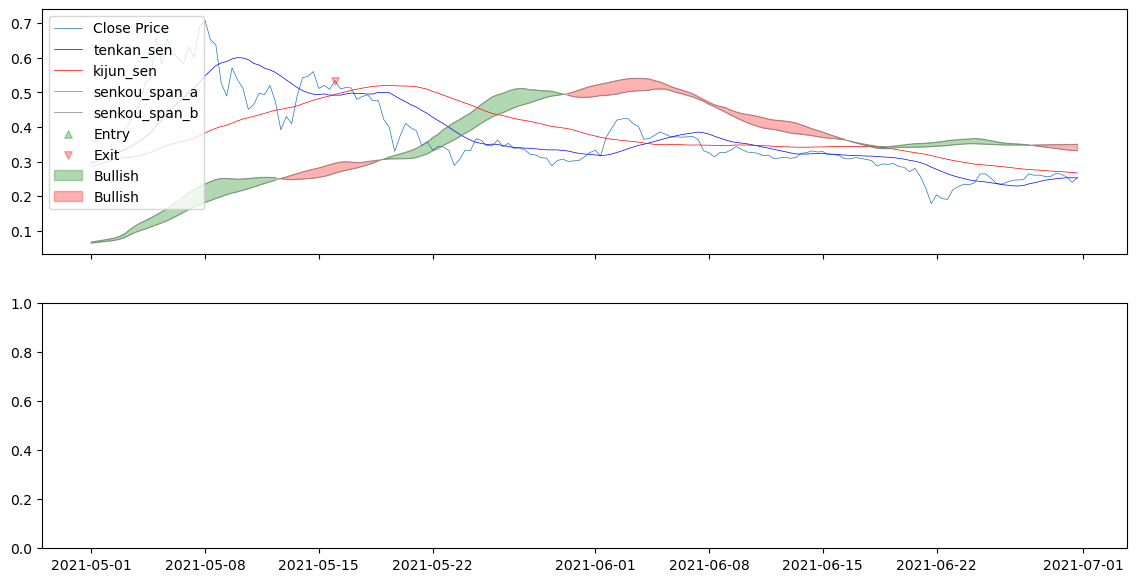

In [70]:

# Define transaction costs and slippage
transaction_cost = 0.001  # 0.1% transaction cost per trade
slippage = 0.001  # 0.1% slippage per trade



# Define the fitness function
# def calculate_indicators(data, params):
def indicators(data, params):    
    tenkan_period, kijun_period, senkou_span_b_period = params
    
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)

                #   (data['close'] > data['kijun_sen']) & \
    data['bull'] = (data['tenkan_sen'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_a']) & \
                  (data['close'] > data['senkou_span_b'])

    data['exit'] =  (data['close'] < data['senkou_span_a']) | \
                   (data['close'] < data['senkou_span_b'])

    
def backtest(data):    
    # Initialize the 'position' column
    data['position'] = 0
    
    # Set the 'position' column based on the signals
    data.loc[data['bull'], 'position'] = 1
    
    # Exit position when exit signal is True
    data.loc[data['exit'], 'position'] = 0
    
    # Forward fill the position to maintain the position until a signal changes
    # data['position'] = data['position'].replace(to_replace=0, method='ffill')
    
    # Calculate number of trades
    data['trade'] = data['position'].diff().abs()
    number_of_trades = data['trade'].sum() / 2  # Each trade consists of an entry and an exit
    
    # Calculate strategy returns
    data['strategy_returns'] = data['position'].shift(1) * data['close'].pct_change()
      
    # Apply transaction costs and slippage only on trades
    data['strategy_returns'] -= data['trade'] * (transaction_cost + slippage)

    data['cumulative_returns'] = (1 + data['strategy_returns']).cumprod()
    
    # Calculate performance metrics
    total_return = data['cumulative_returns'].iloc[-1] - 1
    annualized_return = data['strategy_returns'].mean() * 365 * 24 / 8  # Assuming 8-hour bars
    annualized_volatility = data['strategy_returns'].std() * np.sqrt(365 * 24 / 8)
    sharpe_ratio = annualized_return / annualized_volatility
 
    # Calculate trade returns
    data['trade_returns'] = data['strategy_returns'] * data['trade'].shift(-1)

    # Calculate winning trades and losing trades
    winning_trades = data['trade_returns'][data['trade_returns'] > 0]
    losing_trades = data['trade_returns'][data['trade_returns'] <= 0]

    # Calculate win ratio
    if number_of_trades > 0:
        win_ratio = len(winning_trades) / number_of_trades
    else:
        win_ratio = np.nan

    # Calculate average win and average loss
    average_win = winning_trades.mean() if len(winning_trades) > 0 else np.nan
    average_loss = losing_trades.mean() if len(losing_trades) > 0 else np.nan
    
    return sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss

def optimize(data):
    # Define the objective function for Optuna
    def objective(trial):
        tenkan_period = trial.suggest_int('tenkan_period', 7, 50)
        kijun_period = trial.suggest_int('kijun_period', 50, 100)
        senkou_span_b_period = trial.suggest_int('senkou_span_b_period', 7, 50)
        # ema_margin_atr_mult = trial.suggest_uniform('ema_margin_atr_mult', 0.1, 5)
        
        params = (tenkan_period, kijun_period, senkou_span_b_period)
        indicators(data,params)
        sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss = backtest(data)        
        # tenkan_period, kijun_period, senkou_span_b_period = params        
        return sharpe_ratio #/ math.cos(number_of_trades)

    # Run the optimization
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=100)

    # Get the best parameters
    return study
    

def print_performance(data,best_params, window=None):
    # Set default window to the entire DataFrame if not provided
    if window is None:
        window = data.index
    
    # ema_fast_len, ema_slow_len, ema_margin_atr_len, ema_margin_atr_mult
    indicators(
        data, 
        [best_params['tenkan_period'],best_params['kijun_period'],best_params['senkou_span_b_period']]
        )
    windowed_data = data.loc[window].copy()
    sharpe_ratio,total_return,annualized_return,number_of_trades,win_ratio,average_win,average_loss = backtest(windowed_data)
    
    # Identify trade entries and exits
    entry_points = windowed_data.index[(windowed_data['trade'] == 1) & (windowed_data['position'] == 1)]
    exit_points = windowed_data.index[(windowed_data['trade'] == 1) & (windowed_data['position'] == 0)]

# senkou_span_a
    # Plot the results with the best parameters
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    # plt.figure(figsize=(14, 3))
    ax1.plot(windowed_data.index, windowed_data['close'], label='Close Price',lw=0.5)
    ax1.plot(windowed_data.index, windowed_data['tenkan_sen'], label='tenkan_sen', color='blue',lw=0.5)
    ax1.plot(windowed_data.index, windowed_data['kijun_sen'], label='kijun_sen', color='red',lw=0.5)
    ax1.plot(windowed_data.index, windowed_data['senkou_span_a'], label='senkou_span_a', color='gray',lw=0.5)
    ax1.plot(windowed_data.index, windowed_data['senkou_span_b'], label='senkou_span_b', color='gray',lw=0.5)
    ax1.scatter(entry_points, data.loc[entry_points, 'close'], marker='^', color='g', s=30, label='Entry', zorder=5,alpha=0.3)
    ax1.scatter(exit_points, data.loc[exit_points, 'close'], marker='v', color='r', s=30, label='Exit', zorder=5,alpha=0.3)
    ax1.fill_between(windowed_data.index, windowed_data['senkou_span_a'], windowed_data['senkou_span_b'], where=(windowed_data['senkou_span_a'] > windowed_data['senkou_span_b']), color='green', alpha=0.3, label='Bullish')
    ax1.fill_between(windowed_data.index, windowed_data['senkou_span_a'], windowed_data['senkou_span_b'], where=(windowed_data['senkou_span_a'] < windowed_data['senkou_span_b']), color='red', alpha=0.3, label='Bullish')
    ax1.legend(loc='best')
    plt.title('{BASE}/{QUOTE} Price and Ichimoku Cloud with Optimized Strategy Signals')


    # ax2 = plt.twinx()
    # ax2.plot(windowed_data.index, windowed_data['cumulative_returns'], label='Cumulative Returns', color='purple', lw=0.3)
    ax1.grid()
    # plt.show()

    # Plot cumulative returns with the best parameters
    ax2.figure(figsize=(14, 3))
    ax2.plot(windowed_data.index, windowed_data['cumulative_returns'], label='Cumulative Returns', color='purple')
    ax2.legend(loc='best')
    # ax2.title('Cumulative Returns of the Optimized Strategy')
    ax2.grid()
    plt.show()

    # Print final cumulative return with the best parameters
    print(f"Final Cumulative Return with Optimized Parameters: {windowed_data['cumulative_returns'].iloc[-1]:.2f}")

    # Print performance metrics
    print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
    print(f"Total Return: {total_return:.2f}")
    print(f"Annualized Return: {annualized_return:.2f}")
    print(f"Number of Trades: {number_of_trades:.0f}")
    print(f"Win Ratio: {win_ratio:.2f}")
    print(f"Average Win: {average_win:.4f}")
    print(f"Average Loss: {average_loss:.4f}")
    

# Load the data
data = load_candles('DOGE','USDT','8h')
# data = data['2021-11-01':].copy()
study = optimize(data)
best_params = study.best_params
window = data['2021-05':'2021-06'].index
print_performance(data,best_params,window=window)
print(f'Best params: {best_params}')

[I 2024-08-03 22:36:32,865] A new study created in memory with name: no-name-f4ad15f6-e120-476a-bde9-8e06820aa5e3
[I 2024-08-03 22:36:32,873] Trial 0 finished with value: 1.294034630505587 and parameters: {'tenkan_period': 14, 'kijun_period': 75, 'senkou_span_b_period': 17}. Best is trial 0 with value: 1.294034630505587.
[I 2024-08-03 22:36:32,879] Trial 1 finished with value: 1.4129428595596067 and parameters: {'tenkan_period': 49, 'kijun_period': 94, 'senkou_span_b_period': 43}. Best is trial 1 with value: 1.4129428595596067.
[I 2024-08-03 22:36:32,886] Trial 2 finished with value: 1.5509929416232435 and parameters: {'tenkan_period': 45, 'kijun_period': 84, 'senkou_span_b_period': 18}. Best is trial 2 with value: 1.5509929416232435.
[I 2024-08-03 22:36:32,892] Trial 3 finished with value: 1.5658316281054019 and parameters: {'tenkan_period': 42, 'kijun_period': 92, 'senkou_span_b_period': 48}. Best is trial 3 with value: 1.5658316281054019.
[I 2024-08-03 22:36:32,898] Trial 4 finished

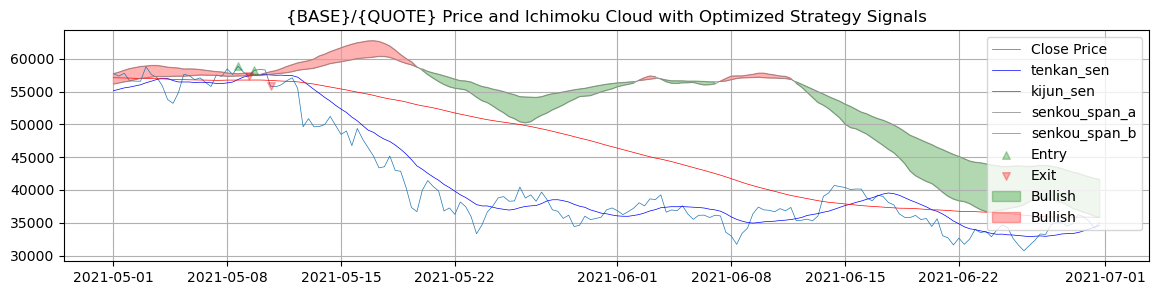

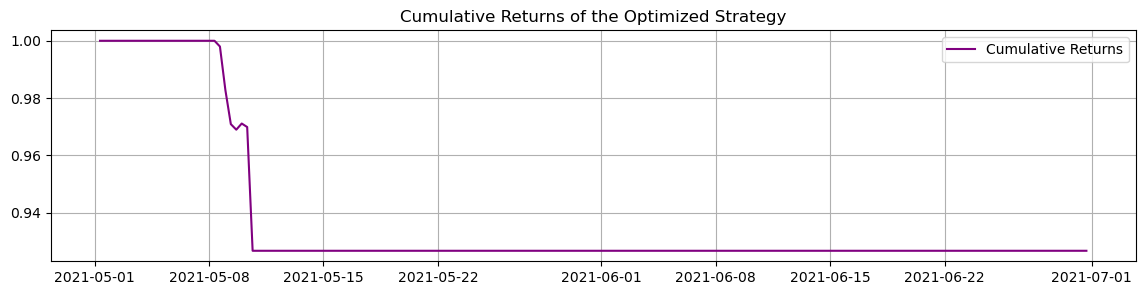

Final Cumulative Return with Optimized Parameters: 0.93
Sharpe Ratio: -3.78
Total Return: -0.07
Annualized Return: -0.45
Number of Trades: 2
Win Ratio: 0.00
Average Win: nan
Average Loss: -0.0002
Best params: {'tenkan_period': 13, 'kijun_period': 91, 'senkou_span_b_period': 11}


In [63]:
# Load the data
data = load_candles('BTC','USDT','8h')
# data = data['2022-01-01':].copy()
study = optimize(data)
best_params = study.best_params
window = window=data['2021-05':'2021-06'].index
print_performance(data,best_params,window=window)
print(f'Best params: {best_params}')

In [ ]:

# Calculate Ichimoku Cloud components
def ichimoku_cloud_log(data, tenkan_period=9, kijun_period=26, senkou_span_b_period=52):
    data['tenkan_sen'] = data['close'].rolling(window=tenkan_period).mean()
    data['kijun_sen'] = data['close'].rolling(window=kijun_period).mean()
    data['senkou_span_a'] = ((data['tenkan_sen'] + data['kijun_sen']) / 2).shift(kijun_period)
    data['senkou_span_b'] = data['close'].rolling(window=senkou_span_b_period).mean().shift(kijun_period)
    return data.dropna()

# Define trading signals
def ichimoku_trading_signals(data):
    buy_signals = (data['tenkan_sen'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_a']) & \
                  (data['close'] > data['kijun_sen']) & \
                  (data['close'] > data['senkou_span_b'])

    sell_signals = (data['close'] < data['senkou_span_a']) | \
                   (data['close'] < data['senkou_span_b'])

    return buy_signals.shift(1).fillna(False), sell_signals.shift(1).fillna(False)

# Fully vectorized backtest without holding period
def fully_vectorized_backtest_no_holding_period(data, buy_signals, sell_signals):
    position = np.zeros(len(data))
    returns = np.ones(len(data))

    for i in range(1, len(data)):
        if buy_signals.iloc[i] and position[i - 1] == 0:
            position[i] = 1  # Buy signal, enter position
        elif position[i - 1] > 0:
            position[i] = 1  # Maintain position

            if sell_signals.iloc[i]:
                returns[i] = data['close'].iloc[i] / data['close'].iloc[np.where(position[:i])[0][-1]]  # Calculate return
                position[i] = 0  # Exit position
        else:
            returns[i] = 1  # No trade, no return

    cumulative_returns = pd.Series(np.cumprod(returns), index=data.index)
    return cumulative_returns

# Genetic Algorithm for parameter optimization
def genetic_algorithm(num_generations, population_size, num_parents):
    # Define the parameter space
    tenkan_range = (5, 30)
    kijun_range = (20, 60)
    senkou_span_b_range = (40, 120)

    # Initialize population
    def initialize_population(size):
        population = []
        for _ in range(size):
            individual = [
                np.random.randint(*tenkan_range),
                np.random.randint(*kijun_range),
                np.random.randint(*senkou_span_b_range)
            ]
            population.append(individual)
        return population

    # Fitness function
    def fitness_function(individual):
        tenkan_period, kijun_period, senkou_span_b_period = individual
        temp_data = ichimoku_cloud_log(data.copy(), tenkan_period, kijun_period, senkou_span_b_period)
        buy_signals, sell_signals = ichimoku_trading_signals(temp_data)
        cumulative_returns = fully_vectorized_backtest_no_holding_period(temp_data, buy_signals, sell_signals)
        final_cumulative_return = cumulative_returns.iloc[-1]
        return final_cumulative_return

    # Selection
    def select_parents(population, fitnesses, num_parents):
        normalized_fitnesses = np.array(fitnesses) / np.sum(fitnesses)
        parents = np.random.choice(np.arange(len(population)), size=num_parents, replace=False, p=normalized_fitnesses)
        return [population[parent] for parent in parents]

    # Crossover
    def crossover(parents):
        offspring = []
        for i in range(0, len(parents), 2):
            parent1 = parents[i]
            parent2 = parents[(i + 1) % len(parents)]
            crossover_point = np.random.randint(1, len(parent1))
            child1 = parent1[:crossover_point] + parent2[crossover_point:]
            child2 = parent2[:crossover_point] + parent1[crossover_point:]
            offspring.extend([child1, child2])
        return offspring

    # Mutation
    def mutate(offspring):
        for individual in offspring:
            if np.random.rand() < 0.1:
                mutation_point = np.random.randint(len(individual))
                if mutation_point == 0:
                    individual[mutation_point] = np.random.randint(*tenkan_range)
                elif mutation_point == 1:
                    individual[mutation_point] = np.random.randint(*kijun_range)
                elif mutation_point == 2:
                    individual[mutation_point] = np.random.randint(*senkou_span_b_range)
        return offspring

    # Genetic Algorithm
    population = initialize_population(population_size)
    best_individual = None
    best_fitness = -float('inf')

    for generation in range(num_generations):
        with ThreadPoolExecutor() as executor:
            fitnesses = list(executor.map(fitness_function, population))
        best_generation_fitness = max(fitnesses)
        best_generation_individual = population[fitnesses.index(best_generation_fitness)]
        
        if best_generation_fitness > best_fitness:
            best_fitness = best_generation_fitness
            best_individual = best_generation_individual
        
        if generation % 2 == 0 or generation == num_generations - 1:
            print(f"Generation {generation}: Best Fitness = {best_fitness}")
        
        parents = select_parents(population, fitnesses, num_parents)
        offspring = crossover(parents)
        offspring = mutate(offspring)
        population = parents + offspring

    return best_individual, best_fitness

# Run the genetic algorithm
best_signal_params_ga, best_cumulative_return_signal_ga = genetic_algorithm(num_generations=10, population_size=10, num_parents=5)
print(f"Best Parameters: {best_signal_params_ga}, Best Cumulative Return: {best_cumulative_return_signal_ga}")

# Apply the optimized parameters to the strategy
optimized_data_ga = ichimoku_cloud_log(data.copy(), best_signal_params_ga[0], best_signal_params_ga[1], best_signal_params_ga[2])
buy_signals, sell_signals = ichimoku_trading_signals(optimized_data_ga)

# Apply the optimized backtest strategy without holding period
cumulative_returns_optimized_ga = fully_vectorized_backtest_no_holding_period(optimized_data_ga, buy_signals, sell_signals)

# Plot the cumulative returns
plt.figure(figsize=(12, 6))
plt.plot(cumulative_returns_optimized_ga, label='Cumulative Returns (Optimized Buy Signals)')
plt.title('Ichimoku Trading Strategy Cumulative Returns (Optimized Buy Signals)')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()

# Calculate risk metrics
def calculate_risk_metrics(cumulative_returns):
    returns = cumulative_returns.pct_change().dropna()
    sharpe_ratio = returns.mean() / returns.std() * np.sqrt(252 * 24 / 8)
    max_drawdown = (cumulative_returns / cumulative_returns.cummax() - 1).min()
    return sharpe_ratio, max_drawdown

sharpe_ratio, max_drawdown = calculate_risk_metrics(cumulative_returns_optimized_ga)
print(f"Sharpe Ratio: {sharpe_ratio}, Max Drawdown: {max_drawdown}")
